### supervised machine learning classification dataset

### Data reading

In [1]:
import keras 
import tensorflow       
from keras.models import Sequential    
from keras.layers import Dense          
from keras.optimizers import Adam 


In [2]:
import pandas as pd
Fru = pd.read_csv(r"C:\ML_Lab\Anaconda\fruit_dataset.csv")
Fru

,weight_g,diameter_cm,sweetness,firmness,fruit
0,174.1,6.98,7.45,7.16,Apple
1,143.5,6.85,7.08,6.28,Apple
2,169.8,7.07,7.53,7.04,Apple
3,170.9,8.06,7.28,5.90,Apple
4,175.0,7.02,7.53,6.47,Apple
...,...,...,...,...,...
195,249.0,9.46,10.00,4.63,Mango
196,250.2,9.62,9.03,3.86,Mango
197,228.4,9.42,8.55,3.12,Mango
198,260.2,9.70,7.93,3.91,Mango


### Data Cleaning

In [3]:
Fru.isnull().sum()

weight_g       0
diameter_cm    0
sweetness      0
firmness       0
fruit          0
dtype: int64

In [4]:
# check "?" mark
for i in Fru.columns:
    print(i,(Fru[i]=='?').sum())

weight_g 0
diameter_cm 0
sweetness 0
firmness 0
fruit 0


### Data vizualization ( plotting )

#### considering fruit ( Category ) as output column.

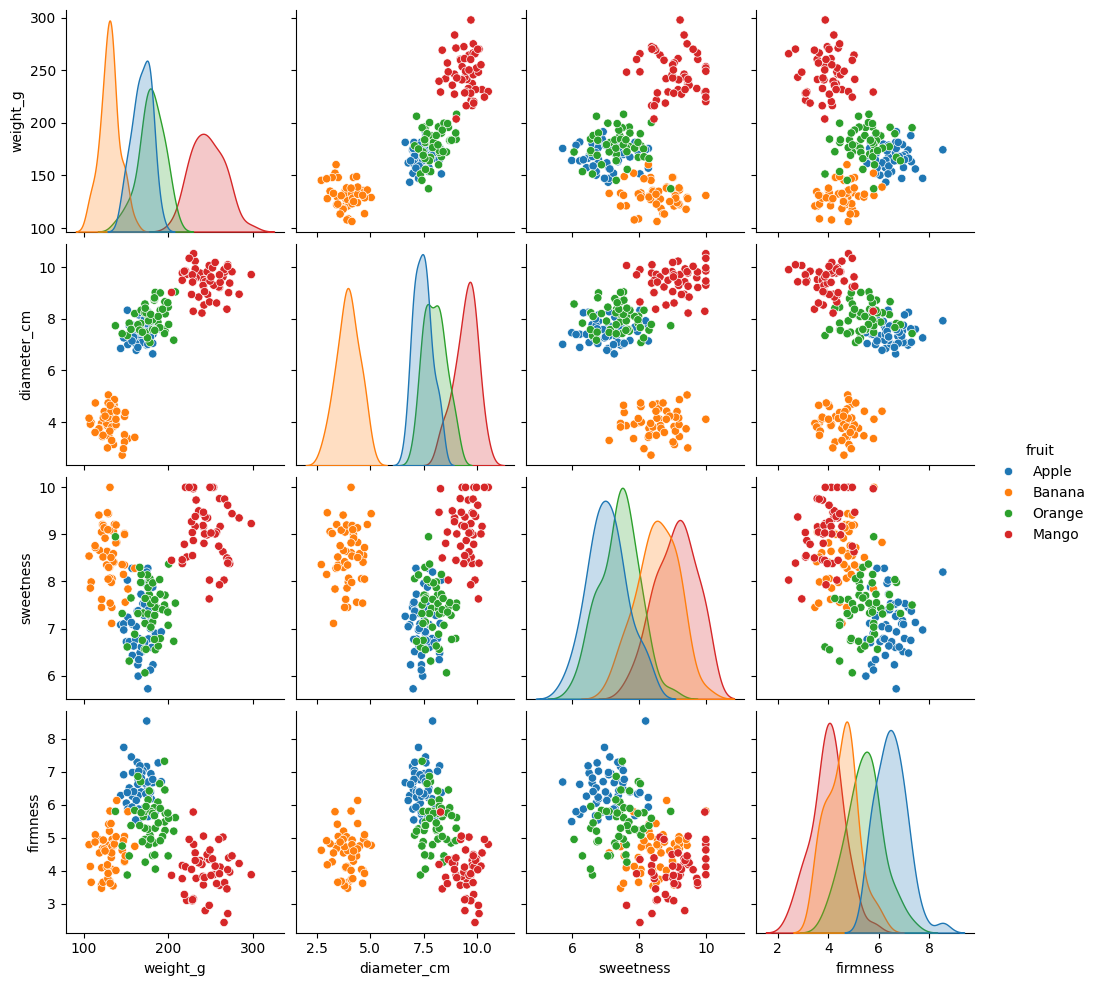

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(Fru,hue='fruit') 
plt.show()

### Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in Fru.columns:
    if Fru[col].dtypes == 'object':
        Fru[col] = le.fit_transform(Fru[col])


In [7]:
Fru.head()

,weight_g,diameter_cm,sweetness,firmness,fruit
0,174.1,6.98,7.45,7.16,0
1,143.5,6.85,7.08,6.28,0
2,169.8,7.07,7.53,7.04,0
3,170.9,8.06,7.28,5.90,0
4,175.0,7.02,7.53,6.47,0


In [8]:
Fru.dtypes

weight_g       float64
diameter_cm    float64
sweetness      float64
firmness       float64
fruit            int64
dtype: object

### Input - Output creation

In [9]:
ip = Fru.drop('fruit',axis=1)
op = Fru['fruit']

In [10]:
ip

,weight_g,diameter_cm,sweetness,firmness
0,174.1,6.98,7.45,7.16
1,143.5,6.85,7.08,6.28
2,169.8,7.07,7.53,7.04
3,170.9,8.06,7.28,5.90
4,175.0,7.02,7.53,6.47
...,...,...,...,...
195,249.0,9.46,10.00,4.63
196,250.2,9.62,9.03,3.86
197,228.4,9.42,8.55,3.12
198,260.2,9.70,7.93,3.91


In [11]:
op

0      0
1      0
2      0
3      0
4      0
      ..
195    2
196    2
197    2
198    2
199    2
Name: fruit, Length: 200, dtype: int64

### Train_test_split

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ip,op,test_size=0.2)

In [13]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

### Deep learning model creation

In [15]:
model = Sequential()

# input layer
model.add(Dense(25,input_dim=4,activation='linear'))   #4 input columns & 1 output col

# Hidden layers 
model.add(Dense(25,activation='linear'))
model.add(Dense(35,activation='linear'))
model.add(Dense(45,activation='linear'))

# output
model.add(Dense(1,activation='linear'))
model.compile(Adam(learning_rate=0.01),loss='mae')  # MAE : mean absolute error

In [16]:
# model_fit
model.fit(x_train,y_train,epochs=20,validation_data=(x_test,y_test))

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 1.5217 - val_loss: 0.5502
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9178 - val_loss: 0.9253
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9815 - val_loss: 0.9949
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8679 - val_loss: 0.7735
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7890 - val_loss: 0.6937
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7849 - val_loss: 0.7342
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7923 - val_loss: 0.6906
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7937 - val_loss: 0.6830
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7857 - val_loss: 0.6358
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7654 - val_loss: 0.6815
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7723 - val_loss: 0.6791
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7752 - val_loss: 0.6531
E

In [17]:
pred = model.predict(x_test)
pred

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[1.3938216 ],
       [1.1216697 ],
       [1.2732521 ],
       [1.0838727 ],
       [1.0250376 ],
       [1.9131058 ],
       [1.8269123 ],
       [1.8129691 ],
       [1.1678463 ],
       [1.030935  ],
       [1.4497249 ],
       [2.1491013 ],
       [0.65832573],
       [1.1439378 ],
       [1.1463169 ],
       [1.8407466 ],
       [1.9792092 ],
       [1.2714565 ],
       [0.6974327 ],
       [0.8005433 ],
       [1.8984956 ],
       [1.3117181 ],
       [1.2545872 ],
       [1.1501212 ],
       [1.1620201 ],
       [1.2009398 ],
       [0.6498669 ],
       [1.8936763 ],
       [1.809206  ],
       [1.1027511 ],
       [1.9437997 ],
       [0.90338135],
       [1.8063868 ],
       [1.4820797 ],
       [1.0887492 ],
       [0.798556  ],
       [1.7300341 ],
       [1.8446792 ],
       [0.6783741 ],
       [1.8241338 ]], dtype=float32)

In [18]:
from sklearn.metrics import mean_absolute_error,r2_score
mae = mean_absolute_error(y_test,pred)
r2 = r2_score(y_test,pred)
print("mae:",mae)
print("r2:",r2)

mae: 0.7050526142120361
r2: 0.27032506465911865
